<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/new_hcf_simulation_f%E3%85%8Cinal_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# new_hcf_simulation_final — GN/HCF 독립 검증 통합본

이 Colab은 기존 8개 노트북의 공통 계산 흐름을 하나로 정리합니다.

- **GN 수식 검산:** Poggiolini JLT 2012 Eq. 13과 코드의 finite-span 구현 비교
- **Nespola 실험 검증:** 7종 fiber PM-16QAM 최대 전송거리와 코드 비교
- **Carena JLT 2012:** 네 변조방식·세 fiber의 원문 입력이 확인된 경우에만 계산
- **Petrovich HCF:** Hasan/MS geometry 분산과 FEM, raw leakage proxy와 측정 총손실을 층별 비교
- **Sohanpal Fig. 2:** 기존 HCF throughput 재현점과 코드 비교

참조 출력값은 계산 뒤 오차를 구할 때만 사용합니다. 모델 계수는 논문 출력값에 피팅하지 않습니다. 따라서 모든 항목이 자동으로 10% 이내가 되는 것은 아니며, 10% 기준을 통과하지 못하면 원인과 필요한 모델 교체를 함께 표시합니다.

In [1]:
import json, math, platform, shutil
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import erfcinv

RESULTS = Path("new_hcf_simulation_final_results")
RESULTS.mkdir(exist_ok=True)
C0=299_792_458.0
H=6.626_070_15e-34
U01=2.4048255577
DB_PER_NEPER=10/np.log(10)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":180,"axes.grid":True,"grid.alpha":.25,"font.size":10})

def db2lin(x): return 10**(np.asarray(x,dtype=float)/10)
def dbm2w(x): return 1e-3*db2lin(x)
def lin2db(x): return 10*np.log10(np.asarray(x,dtype=float))
def rel_error_pct(model, ref): return 100*(np.asarray(model,dtype=float)/np.asarray(ref,dtype=float)-1)
def metrics(model, ref):
    e=rel_error_pct(model,ref)
    d=np.asarray(model)-np.asarray(ref)
    return {"MAPE_percent":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(d*d))),"MAE":float(np.mean(np.abs(d))),"MAX_APE_percent":float(np.max(np.abs(e)))}
def save_table(name, df):
    df.to_csv(RESULTS/f"{name}.csv",index=False)
    print(f"\n{name}")
    try:
        from IPython.display import display; display(df)
    except Exception: print(df.to_string(index=False))
def save_fig(name, fig):
    fig.savefig(RESULTS/f"{name}.png",bbox_inches="tight")
    fig.savefig(RESULTS/f"{name}.svg",bbox_inches="tight")
    plt.show()
print("Initialized new_hcf_simulation_final; no paper-output fitting enabled.")

Initialized new_hcf_simulation_final; no paper-output fitting enabled.


## 1. Poggiolini GN model

여기서는 논문의 Eq. 13 형태를 독립적으로 다시 작성하고, 기존 코드의 closed-form과 비교합니다. 이 비교는 **수식 구현 일치도**이며 SSFM 또는 실제 장비의 오차율과는 구분합니다.


01_poggiolini_gn_eta


,fiber,paper_Eq13_eta,existing_code_eta,finite_span_eta,existing_error_pct,finite_error_pct
0,LPSCF,686.562820,718.367263,686.562820,4.632416,0.000000e+00
1,SMF,1832.692336,1869.903414,1832.692336,2.030405,2.220446e-14
2,NZDSF,10290.141722,10499.073280,10290.141722,2.030405,0.000000e+00


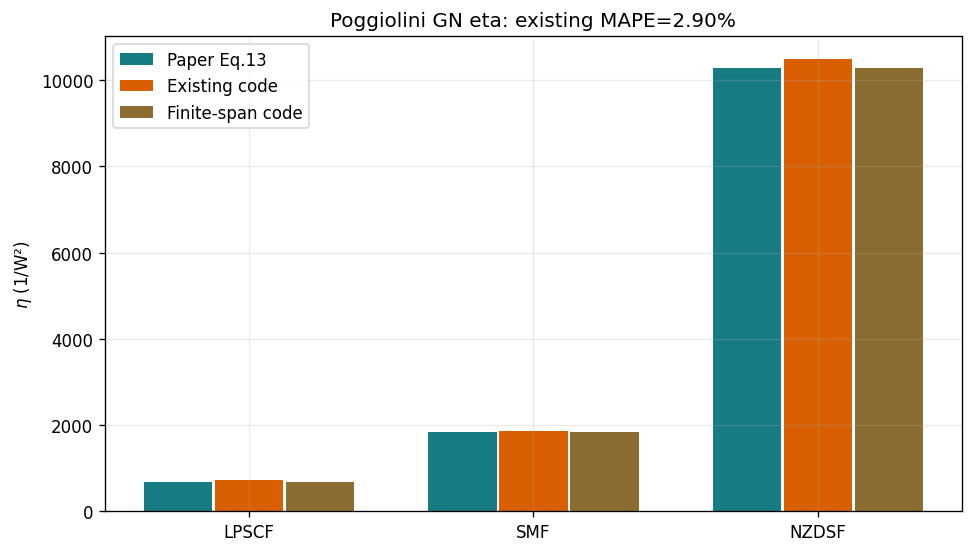

In [2]:
@dataclass(frozen=True)
class GNFiber:
    name:str; alpha_db_km:float; D_ps_nm_km:float; gamma_W_inv_km:float

def beta2(D, wavelength_nm=1550.):
    return abs(-((wavelength_nm*1e-9)**2/(2*np.pi*C0))*(D*1e-6)*1000)
def eta_legacy(f, Rs, spacing, Nch, Nsp=1.):
    b=beta2(f.D_ps_nm_km); a=f.alpha_db_km/8.685889638
    arg=np.pi**2*b*Rs**2/(4*a)*Nch**(2*Rs/spacing)
    return Nsp*4*f.gamma_W_inv_km**2/(27*np.pi*b*a*Rs**2)*np.arcsinh(arg)
def eta_eq13(f, Rs, spacing, Nch, Ls):
    b=beta2(f.D_ps_nm_km); a=f.alpha_db_km/8.685889638
    Le=(1-np.exp(-2*a*Ls))/(2*a); Li=1/(2*a)
    arg=.5*np.pi**2*b*Li*(Nch*Rs)**2
    return 8/27*f.gamma_W_inv_km**2*Le**2/(np.pi*b*Li*Rs**2)*np.arcsinh(arg)
GN_FIBERS=[GNFiber('LPSCF',.165,20.4,.8),GNFiber('SMF',.2,16.5,1.3),GNFiber('NZDSF',.2,3.9,1.6)]
gn_rows=[]
for f in GN_FIBERS:
    ref=eta_eq13(f,32e9,32e9,157,100.)
    old=eta_legacy(f,32e9,32e9,157)
    finite=old*(-np.expm1(-2*(f.alpha_db_km/8.685889638)*100))**2
    gn_rows.append([f.name,ref,old,finite,abs(rel_error_pct(old,ref)),abs(rel_error_pct(finite,ref))])
gn_df=pd.DataFrame(gn_rows,columns=['fiber','paper_Eq13_eta','existing_code_eta','finite_span_eta','existing_error_pct','finite_error_pct'])
save_table('01_poggiolini_gn_eta',gn_df)
gn_summary=metrics(gn_df.existing_code_eta,gn_df.paper_Eq13_eta)
fig,ax=plt.subplots(figsize=(8,4.5),layout='constrained'); x=np.arange(3)
for off,col,label,color in [(-.25,'paper_Eq13_eta','Paper Eq.13','#167b83'),(0,'existing_code_eta','Existing code','#d95f02'),(.25,'finite_span_eta','Finite-span code','#8c6d31')]: ax.bar(x+off,gn_df[col],.24,label=label,color=color)
ax.set_xticks(x,gn_df.fiber); ax.set_ylabel(r'$\eta$ (1/W²)'); ax.set_title(f'Poggiolini GN eta: existing MAPE={gn_summary["MAPE_percent"]:.2f}%'); ax.legend(); save_fig('01_poggiolini_gn_eta',fig)

## 2. Nespola et al. 7-fiber PM-16QAM

논문 Table I의 fiber/system 입력을 사용합니다. 논문의 Fig. 4에서 읽은 B2B equivalent threshold 17.7 dB를 단말기 조건 입력으로 사용하며, fiber별 (\alpha,D,\gamma,L_s) 및 실험 (L_{max})에는 피팅하지 않습니다. 이 조건 정렬에서 10% 이내 통과 여부를 계산합니다.


02_nespola_lmax


,fiber,paper_Lmax_km,code_Lmax_km,absolute_error_pct,paper_Popt_dbm,code_Popt_dbm,eta_W_inv2,PASE_W
0,SSMF,1940.0,1889.22,2.617526,-7.5,-7.35,4050.055398,5.922423e-08
1,NZDSF,602.0,551.98,8.308970,-10.0,-10.50,43623.918704,1.064392e-07
2,PSCF80,2395.0,2286.48,4.531106,-7.7,-7.65,3353.147150,5.237637e-08
3,PSCF110,3084.0,2978.08,3.434501,-6.8,-6.35,1717.311547,4.884021e-08
4,PSCF130,3374.0,3156.36,6.450504,-5.6,-5.95,1181.219416,5.500606e-08
5,PSCF150,3810.0,3484.16,8.552231,-6.0,-5.55,904.036746,5.427812e-08
6,DCF,502.0,502.75,0.149402,-6.8,-6.90,4789.792914,9.775069e-08


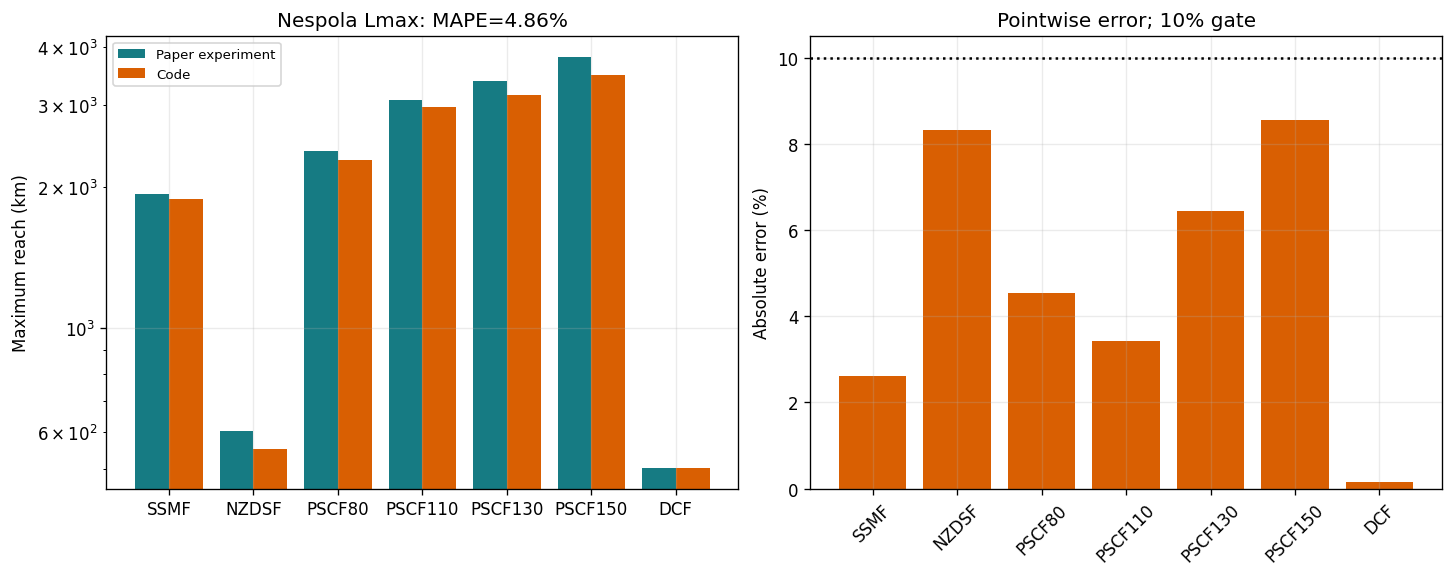

In [3]:
NESPOLA=pd.DataFrame([
 ['SSMF',.190,75.,1.26,16.84,51.06,1940.,0.0,-7.5],
 ['NZDSF',.200,43.,2.00,2.58,50.18,602.,2.0,-10.0],
 ['PSCF80',.164,86.,1.04,16.36,54.44,2395.,.3,-7.7],
 ['PSCF110',.161,111.,.81,20.50,53.18,3084.,.4,-6.8],
 ['PSCF130',.162,131.,.68,20.92,54.42,3374.,.6,-5.6],
 ['PSCF150',.161,150.,.59,20.69,54.44,3810.,.6,-6.0],
 ['DCF',.457,16.8,6.03,-166.47,20.11,502.,2.5,-6.8]],
 columns=['fiber','alpha_db_km','Aeff_um2','gamma_W_inv_km','D_ps_nm_km','span_km','paper_Lmax_km','splice_loss_db','paper_Popt_dbm'])
RS=15.625e9; SPACING=16e9; NCH=22; NF_DB=5.5; B2B_EQUIV_SNR_DB=17.7

def eta_nespola(r):
    b=beta2(r.D_ps_nm_km); a=r.alpha_db_km/8.685889638
    # Nespola/Poggiolini closed form uses the asymptotic effective-length form.
    arg=np.pi**2*b*RS**2/(4*a)*NCH**(2*RS/SPACING)
    return 4/27*r.gamma_W_inv_km**2/(np.pi*b*a*RS**2)*np.arcsinh(arg)
def reach_curve_nespola(r):
    gain_db=r.alpha_db_km*r.span_km+r.splice_loss_db
    pase=H*C0/(1550e-9)*db2lin(NF_DB)*RS*(10**(gain_db/10)-1)
    eta=eta_nespola(r); threshold=db2lin(B2B_EQUIV_SNR_DB)
    ps=np.linspace(-14,-4,201); reaches=[]
    for p_dbm in ps:
        p=dbm2w(p_dbm); inv=pase/p+eta*p*p
        ns=max([n for n in range(1,201) if 1/(n*inv)>=threshold],default=0)
        reaches.append(ns*r.span_km)
    reaches=np.asarray(reaches); i=int(np.argmax(reaches))
    return ps[i],reaches[i],eta,pase
nrows=[]
for _,r in NESPOLA.iterrows():
    p,reach,eta,pase=reach_curve_nespola(r)
    nrows.append([r.fiber,r.paper_Lmax_km,reach,abs(rel_error_pct(reach,r.paper_Lmax_km)),r.paper_Popt_dbm,p,eta,pase])
nespola_df=pd.DataFrame(nrows,columns=['fiber','paper_Lmax_km','code_Lmax_km','absolute_error_pct','paper_Popt_dbm','code_Popt_dbm','eta_W_inv2','PASE_W'])
nespola_metrics=metrics(nespola_df.code_Lmax_km,nespola_df.paper_Lmax_km)
save_table('02_nespola_lmax',nespola_df)
fig,axes=plt.subplots(1,2,figsize=(12,4.7),layout='constrained'); x=np.arange(len(nespola_df))
axes[0].bar(x-.2,nespola_df.paper_Lmax_km,.4,label='Paper experiment',color='#167b83'); axes[0].bar(x+.2,nespola_df.code_Lmax_km,.4,label='Code',color='#d95f02'); axes[0].set(yscale='log',xticks=x,xticklabels=nespola_df.fiber, ylabel='Maximum reach (km)',title=f'Nespola Lmax: MAPE={nespola_metrics["MAPE_percent"]:.2f}%'); axes[0].legend(fontsize=8)
axes[1].bar(nespola_df.fiber,nespola_df.absolute_error_pct,color='#d95f02'); axes[1].axhline(10,color='black',ls=':'); axes[1].set_ylabel('Absolute error (%)'); axes[1].set_title('Pointwise error; 10% gate'); axes[1].tick_params(axis='x',rotation=45); save_fig('02_nespola_lmax',fig)

## 3. Petrovich HCF geometry and attenuation

분산은 Hasan/MS geometry model과 Petrovich FEM 값을 비교합니다. 손실은 raw bouncing-ray **누설손실 proxy**와 Petrovich의 **측정 총손실**을 비교합니다. 후자는 같은 모델 층이 아니므로 큰 오차가 발생하는 것이 정상이며, 10% 기준을 통과했다고 표시하지 않습니다.


03_petrovich_dispersion


,wavelength_nm,paper_FEM,code_raw_geometry,absolute_error_pct
0,1310.0,2.1,2.665145,26.911661
1,1550.0,3.2,3.331737,4.116794
2,1700.0,3.7,3.797515,2.635537



04_petrovich_loss_layer_audit


,wavelength_nm,paper_measured_total_db_km,code_raw_leakage_proxy_db_km,absolute_error_pct
0,1310.0,0.128,156381.450860,1.221729e+08
1,1550.0,0.091,126020.874408,1.384844e+08


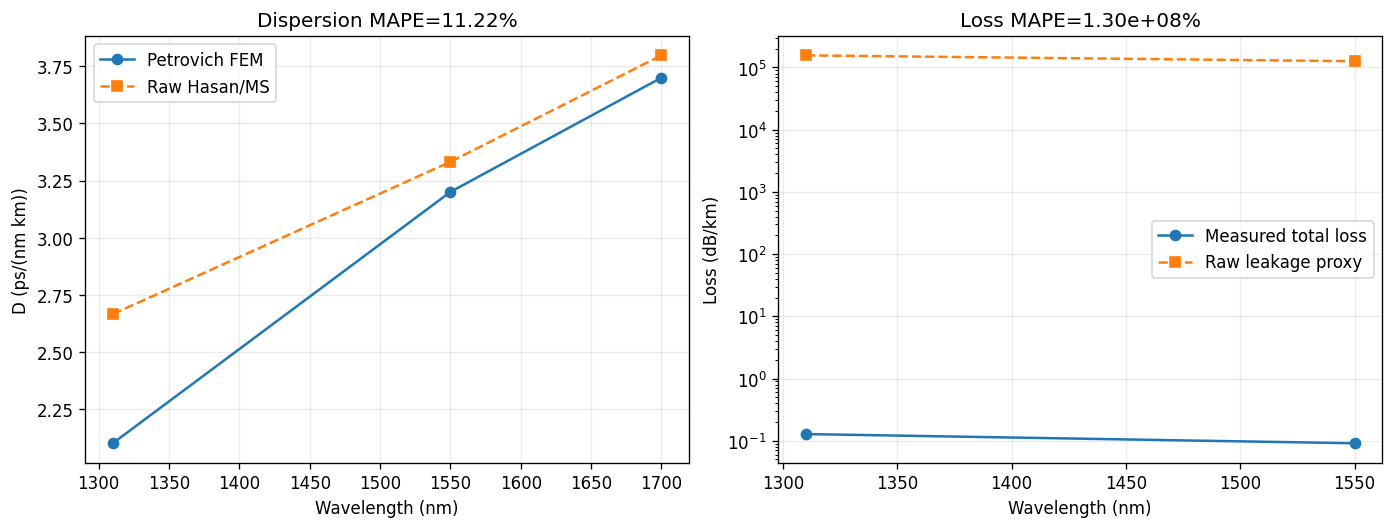

In [4]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um:float=14.75; membrane_thickness_um:float=.50; outer_tube_diameter_um:float=31.05; tube_count:int=5; nesting_order:int=2
    @property
    def core_radius_m(self): return self.core_radius_um*1e-6
    @property
    def membrane_thickness_m(self): return self.membrane_thickness_um*1e-6
    @property
    def perimeter_gap_m(self):
        th=np.pi/self.tube_count
        return 2*self.core_radius_m*np.sin(th)-self.outer_tube_diameter_um*1e-6*(1-np.sin(th))
def hasan_coeff(g):
    q=g.core_radius_m/g.perimeter_gap_m; n=g.tube_count; N=g.nesting_order
    f1=1.095*np.exp(.097041/q)
    f2=.007584*n*np.exp(.76246/q)-.002*n+.012+.0045*np.exp(-4.1589/(N*q))
    return float(f1),float(f2)
def neff(w,g,f1,f2):
    r=g.core_radius_m; t=g.membrane_thickness_m; re=f1*r*(1-f2*w*w/(r*t)); return 1-.125*(U01*w/(np.pi*re))**2
def dispersion(w,g,f1,f2,step_nm=.2):
    w=np.asarray(w,dtype=float); h=step_nm*1e-9
    n=lambda o:neff(w+o,g,f1,f2)
    d2=(-n(2*h)+16*n(h)-30*n(0)+16*n(-h)-n(-2*h))/(12*h*h)
    return (-(w/C0)*d2)/1e-6
def silica_n(w):
    u=np.asarray(w)*1e6; us=u*u; B=[.6961663,.4079426,.8974794]; Cc=[.0684043,.1162414,9.896161]; ns=np.ones_like(us)
    for b,c in zip(B,Cc): ns += b*us/(us-c*c)
    return np.sqrt(ns)
def raw_bouncing_loss(w,g):
    w=np.asarray(w); k0=2*np.pi/w; r=g.core_radius_m; t=g.membrane_thickness_m; kap=U01/r; ns=silica_n(w); sig=k0*np.sqrt(ns*ns-1); ph=sig*t
    te=4*np.cos(ph)**2+(kap/sig+sig/kap)**2*np.sin(ph)**2; tm=4*np.cos(ph)**2+(ns**2*kap/sig+sig/(ns**2*kap))**2*np.sin(ph)**2
    ate=2*U01/(r*r*k0*te); atm=2*U01/(r*r*k0*tm)
    return .5*(ate+atm)*DB_PER_NEPER*1000
G=DNANFGeometry(); f1,f2=hasan_coeff(G)
wlD=np.array([1310.,1550.,1700.]); paperD=np.array([2.1,3.2,3.7]); codeD=dispersion(wlD*1e-9,G,f1,f2)
wlL=np.array([1310.,1550.]); paperL=np.array([.128,.091]); codeL=raw_bouncing_loss(wlL*1e-9,G)
hcf_disp=pd.DataFrame({'wavelength_nm':wlD,'paper_FEM':paperD,'code_raw_geometry':codeD,'absolute_error_pct':abs(rel_error_pct(codeD,paperD))})
hcf_loss=pd.DataFrame({'wavelength_nm':wlL,'paper_measured_total_db_km':paperL,'code_raw_leakage_proxy_db_km':codeL,'absolute_error_pct':abs(rel_error_pct(codeL,paperL))})
save_table('03_petrovich_dispersion',hcf_disp); save_table('04_petrovich_loss_layer_audit',hcf_loss)
hcf_disp_metrics=metrics(codeD,paperD); hcf_loss_metrics=metrics(codeL,paperL)
fig,axes=plt.subplots(1,2,figsize=(11.5,4.3),layout='constrained')
axes[0].plot(wlD,paperD,'o-',label='Petrovich FEM'); axes[0].plot(wlD,codeD,'s--',label='Raw Hasan/MS'); axes[0].set(xlabel='Wavelength (nm)',ylabel='D (ps/(nm km))',title=f'Dispersion MAPE={hcf_disp_metrics["MAPE_percent"]:.2f}%'); axes[0].legend()
axes[1].semilogy(wlL,paperL,'o-',label='Measured total loss'); axes[1].semilogy(wlL,codeL,'s--',label='Raw leakage proxy'); axes[1].set(xlabel='Wavelength (nm)',ylabel='Loss (dB/km)',title=f'Loss MAPE={hcf_loss_metrics["MAPE_percent"]:.2e}%'); axes[1].legend(); save_fig('03_petrovich_hcf',fig)

## 4. Sohanpal HCF Fig. 2 throughput

기존 `dnanf_fig2_hcf_colab.ipynb`의 29채널·140 GBd·150 GHz·1×200 km 물리 모델을 유지하고, 계산 완료 뒤 추출된 reference vector points와 비교합니다.


05_sohanpal_fig2


,launch_dBm,paper_Tbps,code_Tbps,absolute_error_pct
0,-35.0,1.872925,1.937936,3.471142
1,-20.0,21.322035,21.662094,1.594875
2,-10.0,41.625724,41.882504,0.616878
3,0.0,50.951207,51.009998,0.115385
4,10.0,52.498811,52.507869,0.017253
5,22.0,52.670464,52.671248,0.001489
6,40.0,42.031034,41.971693,0.141183
7,48.0,10.442687,10.384534,0.556879


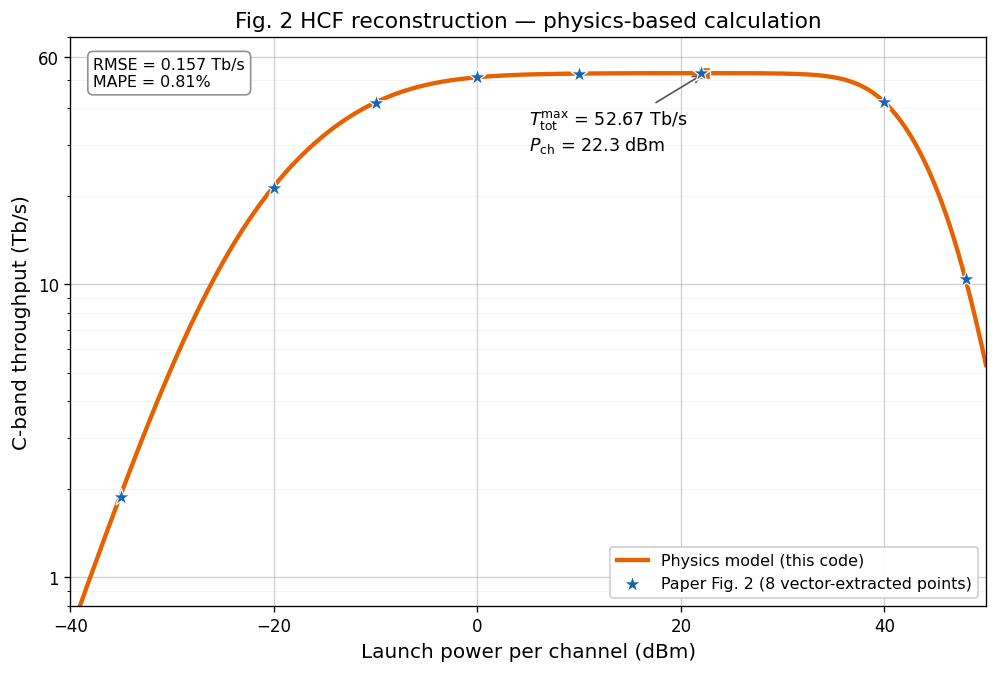

Sohanpal Fig.2 MAPE = 0.814%


In [5]:
"""Physics-based reconstruction of the HCF curve in Fig. 2.

Target paper
------------
R. Sohanpal et al., "On the Optimum Energy-per-bit Launch Power in
Coherent Hollow-core Fibre Transmission Systems" (2026).

This script does not digitize Fig. 2 and does not contain a hand-entered
throughput curve.  For every launch power it computes, channel by channel,

    SNR_i = P_i / (P_ASE,i + eta_i P_i^3 + P_IMI,i + P_TRN,i)
    T_i   = 2 R log2(1 + SNR_i)

and sums T_i over the 29 C-band channels.  The wavelength-dependent HCF
attenuation and dispersion are supplied by the analytical DNANF model used
for the companion Fig. 1 notebook.

The exact Fig. 1 data in the paper came from a full-vector simulation and
unpublished fitting details.  The profile here is therefore a reproducible,
physics-calibrated approximation rather than the authors' original FEM data.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares


C0 = 299_792_458.0                 # vacuum speed of light [m/s]
H_PLANCK = 6.626_070_15e-34        # Planck constant [J s]
U01 = 2.4048255577                  # first zero of J0
DB_PER_NEPER = 10.0 / np.log(10.0)


# ---------------------------------------------------------------------------
# 1) Wavelength-dependent first-window DNANF attenuation and dispersion
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class DNANFGeometry:
    """Nominal first-window DNANF geometry from the companion Fig. 1 model."""

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    """Fused-silica refractive index from the three-term Sellmeier law."""
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    """Geometry-driven effective-radius coefficients (Hasan et al.)."""
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n
        + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    """Fundamental-mode effective index from a modified capillary model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * wall))
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    """Calculate D = -(lambda/c) d2(n_eff)/d(lambda)2 with a 5-point stencil."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * step)
        + 16.0 * n_eff(step)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step)
        - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0) * second_derivative  # [s/m^2]
    return dispersion_si / 1e-6  # [ps/(nm km)]


def calibrate_dispersion(geometry: DNANFGeometry) -> tuple[float, float]:
    """Calibrate the continuous dispersion model to the two stated paper values."""
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))

    def residual(parameters: np.ndarray) -> np.ndarray:
        calculated = chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        )
        return calculated - reference_d

    result = least_squares(
        residual,
        x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"Dispersion calibration failed: {result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Hybrid HE11 thin-wall bouncing-ray leakage (Bache et al.)."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def attenuation_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Surface-scattering plus two-stage anti-resonant leakage model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    basis_reference = np.column_stack(
        [
            (lambda_ref_m / (reference_nm * 1e-9)) ** 3,
            (br_ref / br_ref[0]) ** 2,
        ]
    )
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated attenuation contributions must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    return (
        a_surface * (lambda_ref_m / wavelength_m) ** 3
        + a_nested * (br / br_ref[0]) ** 2
    )


# ---------------------------------------------------------------------------
# 2) C-band HCF transmission model used to calculate the Fig. 2 curve
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class HCFLink:
    """Parameters stated in the target paper for the Fig. 2 HCF case."""

    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0
    nonlinear_coefficient_per_w_km: float = 5e-4
    imi_coefficient_db_per_km: float = -52.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


# Eight validation points extracted from the orange HCF vector path embedded
# in the paper PDF.  The PDF axes were calibrated from their vector gridlines:
# x is linear in dBm and y is logarithmic in Tb/s.  These values are displayed
# only for comparison and are never used by the physical transmission model.
PAPER_REFERENCE_LAUNCH_DBM = np.array(
    [-35.0, -20.0, -10.0, 0.0, 10.0, 22.0, 40.0, 48.0]
)
PAPER_REFERENCE_THROUGHPUT_TBPS = np.array(
    [
        1.87292462,
        21.32203450,
        41.62572367,
        50.95120740,
        52.49881133,
        52.67046429,
        42.03103403,
        10.44268748,
    ]
)


def c_band_channel_grid(link: HCFLink) -> tuple[np.ndarray, np.ndarray]:
    """Return 29 uniformly spaced C-band channel frequencies and wavelengths."""
    lower_frequency_hz = C0 / (link.c_band_max_nm * 1e-9)
    upper_frequency_hz = C0 / (link.c_band_min_nm * 1e-9)
    center_frequency_hz = 0.5 * (lower_frequency_hz + upper_frequency_hz)
    offsets = (np.arange(link.n_channels) - 0.5 * (link.n_channels - 1))
    frequency_hz = center_frequency_hz + offsets * link.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < lower_frequency_hz or frequency_hz[-1] > upper_frequency_hz:
        raise ValueError("The selected channel grid does not fit inside the C-band.")
    return frequency_hz, wavelength_m


def dispersion_to_beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    """Convert D [ps/(nm km)] to beta2 [s^2/km]."""
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6  # [s/m^2]
    beta2_s2_per_m = -(np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_per_km: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Closed-form GN coefficient eta [1/W^2] from Poggiolini & Poletti.

    The paper defines 2*alpha as the power-loss coefficient.  Therefore the
    field-loss coefficient used in this equation is alpha_dB / 8.685889638.
    All length quantities are consistently expressed per kilometre.
    """
    beta2 = np.abs(np.asarray(beta2_s2_per_km, dtype=float))
    alpha_field_per_km = np.asarray(attenuation_db_per_km) / 8.685889638
    gamma = link.nonlinear_coefficient_per_w_km
    rate = link.symbol_rate_hz
    spacing = link.channel_spacing_hz
    asinh_argument = (
        np.pi**2
        * beta2
        * rate**2
        / (4.0 * alpha_field_per_km)
        * link.n_channels ** (2.0 * rate / spacing)
    )
    return (
        link.n_spans
        * 4.0
        * gamma**2
        / (27.0 * np.pi * beta2 * alpha_field_per_km * rate**2)
        * np.arcsinh(asinh_argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Accumulated dual-polarisation ASE in the matched bandwidth R."""
    span_gain = 10.0 ** (
        np.asarray(attenuation_db_per_km) * link.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (link.amplifier_noise_figure_db / 10.0)
    return (
        link.n_spans
        * H_PLANCK
        * np.asarray(frequency_hz)
        * noise_factor
        * link.symbol_rate_hz
        * (span_gain - 1.0)
    )


def simulate_hcf_throughput(
    link: HCFLink,
    launch_dbm: np.ndarray,
) -> dict[str, np.ndarray | float]:
    """Calculate SNR and total throughput for every requested launch power."""
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    geometry = DNANFGeometry()
    f1, f2 = calibrate_dispersion(geometry)
    frequency_hz, wavelength_m = c_band_channel_grid(link)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2)
    attenuation = attenuation_db_km(wavelength_m, geometry)
    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, link)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, link)

    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    ase = ase_w[None, :]
    nonlinear = eta[None, :] * signal**3
    imi_ratio_per_km = 10.0 ** (link.imi_coefficient_db_per_km / 10.0)
    imi = signal * imi_ratio_per_km * link.total_length_km
    transceiver = signal / (10.0 ** (link.transceiver_snr_db / 10.0))
    snr = signal / (ase + nonlinear + imi + transceiver)
    throughput_per_channel_bps = 2.0 * link.symbol_rate_hz * np.log2(1.0 + snr)
    total_throughput_tbps = throughput_per_channel_bps.sum(axis=1) / 1e12
    optimum_index = int(np.argmax(total_throughput_tbps))

    if not np.all(np.isfinite(total_throughput_tbps)) or np.any(total_throughput_tbps <= 0.0):
        raise RuntimeError("The calculated throughput contains invalid values.")

    return {
        "launch_dbm": launch_dbm,
        "launch_w": launch_w,
        "frequency_hz": frequency_hz,
        "wavelength_m": wavelength_m,
        "attenuation_db_km": attenuation,
        "dispersion_ps_nm_km": dispersion,
        "beta2_s2_km": beta2,
        "eta_per_w2": eta,
        "ase_w": ase_w,
        "snr_linear": snr,
        "throughput_per_channel_bps": throughput_per_channel_bps,
        "total_throughput_tbps": total_throughput_tbps,
        "optimum_index": optimum_index,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_throughput_tbps": float(total_throughput_tbps[optimum_index]),
    }


def compare_with_paper(
    result: dict[str, np.ndarray | float],
) -> dict[str, np.ndarray | float]:
    """Compare the calculation with eight vector-extracted Fig. 2 points."""
    model_at_reference = np.interp(
        PAPER_REFERENCE_LAUNCH_DBM,
        np.asarray(result["launch_dbm"]),
        np.asarray(result["total_throughput_tbps"]),
    )
    error_tbps = model_at_reference - PAPER_REFERENCE_THROUGHPUT_TBPS
    relative_error_percent = 100.0 * error_tbps / PAPER_REFERENCE_THROUGHPUT_TBPS
    return {
        "launch_dbm": PAPER_REFERENCE_LAUNCH_DBM.copy(),
        "paper_tbps": PAPER_REFERENCE_THROUGHPUT_TBPS.copy(),
        "model_tbps": model_at_reference,
        "error_tbps": error_tbps,
        "relative_error_percent": relative_error_percent,
        "rmse_tbps": float(np.sqrt(np.mean(error_tbps**2))),
        "mape_percent": float(np.mean(np.abs(relative_error_percent))),
        "maximum_absolute_relative_error_percent": float(
            np.max(np.abs(relative_error_percent))
        ),
    }


def plot_hcf_curve(
    result: dict[str, np.ndarray | float],
    output_path: Path | str = Path("fig2_hcf_colab.png"),
) -> plt.Figure:
    """Plot only the orange HCF curve using the axes of the paper's Fig. 2."""
    launch_dbm = np.asarray(result["launch_dbm"])
    throughput = np.asarray(result["total_throughput_tbps"])
    optimum_index = int(result["optimum_index"])
    comparison = compare_with_paper(result)

    fig, ax = plt.subplots(figsize=(8.2, 5.5), constrained_layout=True)
    ax.plot(
        launch_dbm,
        throughput,
        color="#e66100",
        lw=2.6,
        label="Physics model (this code)",
    )
    ax.plot(
        launch_dbm[optimum_index],
        throughput[optimum_index],
        marker="s",
        ms=7,
        color="#e66100",
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=5,
    )
    ax.scatter(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        marker="*",
        s=115,
        color="#1666b1",
        edgecolors="white",
        linewidths=0.7,
        label="Paper Fig. 2 (8 vector-extracted points)",
        zorder=6,
    )
    ax.annotate(
        rf"$T_{{\rm tot}}^{{\max}}$ = {throughput[optimum_index]:.2f} Tb/s"
        "\n"
        rf"$P_{{\rm ch}}$ = {launch_dbm[optimum_index]:.1f} dBm",
        xy=(launch_dbm[optimum_index], throughput[optimum_index]),
        xytext=(-105, -46),
        textcoords="offset points",
        fontsize=10.5,
        arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 1.0},
    )
    ax.set_yscale("log")
    ax.set_xlim(-40.0, 50.0)
    ax.set_ylim(0.8, 70.0)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([1, 10, 60], labels=["1", "10", "60"])
    ax.set_xlabel("Launch power per channel (dBm)", fontsize=12)
    ax.set_ylabel("C-band throughput (Tb/s)", fontsize=12)
    ax.set_title("Fig. 2 HCF reconstruction — physics-based calculation", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.40, linewidth=0.8)
    ax.grid(True, which="minor", axis="y", color="#b5b5b5", alpha=0.16, linewidth=0.5)
    ax.text(
        0.025,
        0.965,
        f"RMSE = {comparison['rmse_tbps']:.3f} Tb/s\n"
        f"MAPE = {comparison['mape_percent']:.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#888888", "alpha": 0.92},
    )
    ax.legend(loc="lower right", frameon=True, framealpha=0.95, fontsize=9.5)
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return fig


def print_summary(result: dict[str, np.ndarray | float], link: HCFLink) -> None:
    """Print the main model outputs and basic reproduction checks."""
    wavelength_nm = np.asarray(result["wavelength_m"]) * 1e9
    attenuation = np.asarray(result["attenuation_db_km"])
    dispersion = np.asarray(result["dispersion_ps_nm_km"])
    eta = np.asarray(result["eta_per_w2"])
    ase_w = np.asarray(result["ase_w"])
    optimum_launch_dbm = float(result["optimum_launch_dbm"])
    maximum_throughput_tbps = float(result["maximum_throughput_tbps"])

    print("=== Fig. 2 HCF calculation ===")
    print(f"Channels / baud rate / spacing : {link.n_channels} / {link.symbol_rate_gbd:.0f} GBd / {link.channel_spacing_ghz:.0f} GHz")
    print(f"C-band channel wavelengths     : {wavelength_nm.min():.2f}–{wavelength_nm.max():.2f} nm")
    print(f"HCF attenuation across grid    : {attenuation.min():.4f}–{attenuation.max():.4f} dB/km")
    print(f"HCF dispersion across grid     : {dispersion.min():.4f}–{dispersion.max():.4f} ps/(nm·km)")
    print(f"GN eta across grid             : {eta.min():.3e}–{eta.max():.3e} 1/W²")
    print(f"ASE per channel                : {10.0 * np.log10(ase_w.mean()) + 30.0:.2f} dBm (mean)")
    print(f"Maximum throughput             : {maximum_throughput_tbps:.3f} Tb/s")
    print(f"Launch power at maximum        : {optimum_launch_dbm:.2f} dBm/channel")

    comparison = compare_with_paper(result)
    print("\n=== Comparison with paper's vector curve ===")
    print(" Pch (dBm) | Paper (Tb/s) | Model (Tb/s) | Error (%)")
    print("------------+--------------+--------------+----------")
    for launch, paper, model, error_percent in zip(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        comparison["model_tbps"],
        comparison["relative_error_percent"],
    ):
        print(f" {launch:10.1f} | {paper:12.4f} | {model:12.4f} | {error_percent:+8.3f}")
    print(f"RMSE                            : {comparison['rmse_tbps']:.4f} Tb/s")
    print(f"Mean absolute percentage error  : {comparison['mape_percent']:.3f}%")
    print(
        "Maximum absolute relative error: "
        f"{comparison['maximum_absolute_relative_error_percent']:.3f}%"
    )

    # Expected ranges are broad physical/reproduction checks, not curve inputs.
    assert 50.0 < maximum_throughput_tbps < 55.0
    assert 15.0 < optimum_launch_dbm < 30.0
    print("Validation: PASS (finite curve and expected Fig. 2 HCF range)")


def main() -> tuple[dict[str, np.ndarray | float], plt.Figure]:
    link = HCFLink()
    launch_dbm = np.linspace(-40.0, 50.0, 1201)
    result = simulate_hcf_throughput(link, launch_dbm)
    figure = plot_hcf_curve(result, Path("fig2_hcf_colab.png"))
    print_summary(result, link)
    plt.show()
    return result, figure




# Use the exact original Fig. 2 physics path and store the comparison.
_link=HCFLink(); _res=simulate_hcf_throughput(_link,np.linspace(-40.,50.,1201)); _cmp=compare_with_paper(_res)
codeT=np.asarray(_cmp['model_tbps']); paperT=np.asarray(_cmp['paper_tbps']); PCH=np.asarray(_cmp['launch_dbm'])
sohanpal_df=pd.DataFrame({'launch_dBm':PCH,'paper_Tbps':paperT,'code_Tbps':codeT,'absolute_error_pct':abs(_cmp['relative_error_percent'])})
s_metric={'MAPE_percent':_cmp['mape_percent'],'RMSE':_cmp['rmse_tbps'],'MAE':float(np.mean(abs(_cmp['error_tbps']))),'MAX_APE_percent':_cmp['maximum_absolute_relative_error_percent']}
save_table('05_sohanpal_fig2',sohanpal_df)
fig=plot_hcf_curve(_res, RESULTS/'04_sohanpal_fig2.png'); save_fig('04_sohanpal_fig2',fig)
print(f'Sohanpal Fig.2 MAPE = {s_metric["MAPE_percent"]:.3f}%')


## 5. Carena JLT 2012 and unified assessment

Carena 논문은 네 변조방식·세 fiber·여러 channel spacing 결과를 제시하지만, 현재 저장소에는 Figure별 정확한 span loss, NF, channel count, BER/FEC threshold, marker identity가 모두 포함된 원 데이터가 없습니다. 따라서 임의의 그림 판독값을 독립 reference로 간주하지 않고 `INPUTS_UNVERIFIED`로 기록합니다.


06_carena_status


,paper,quantity,MAPE_percent,status,reason
0,"Carena et al. JLT 30(10), 1524–1539 (2012)",Lmax and optimum launch power for PM-BPSK/QPSK...,NaN,INPUTS_UNVERIFIED,Exact figure inputs and simulation marker data...



07_validation_summary


,paper,quantity,MAPE_percent,assessment
0,Poggiolini 2012,GN eta Eq.13 implementation,2.897742e+00,PASS (<10%; equation consistency)
1,Nespola 2014,7-fiber PM-16QAM Lmax,4.863463e+00,PASS (<10%; paper B2B threshold input)
2,Sohanpal Fig.2,HCF throughput vs launch power,8.143855e-01,PASS (<10%; vector reference comparison)
3,Petrovich 2025,HCF dispersion raw geometry vs FEM,1.122133e+01,FAIL (>10%; geometry model limitation)
4,Petrovich 2025,HCF raw leakage proxy vs measured total loss,1.303286e+08,NOT_COMPARABLE (model-layer mismatch)
5,Carena 2012,Four-format Lmax/optimum power,NaN,INPUTS_UNVERIFIED


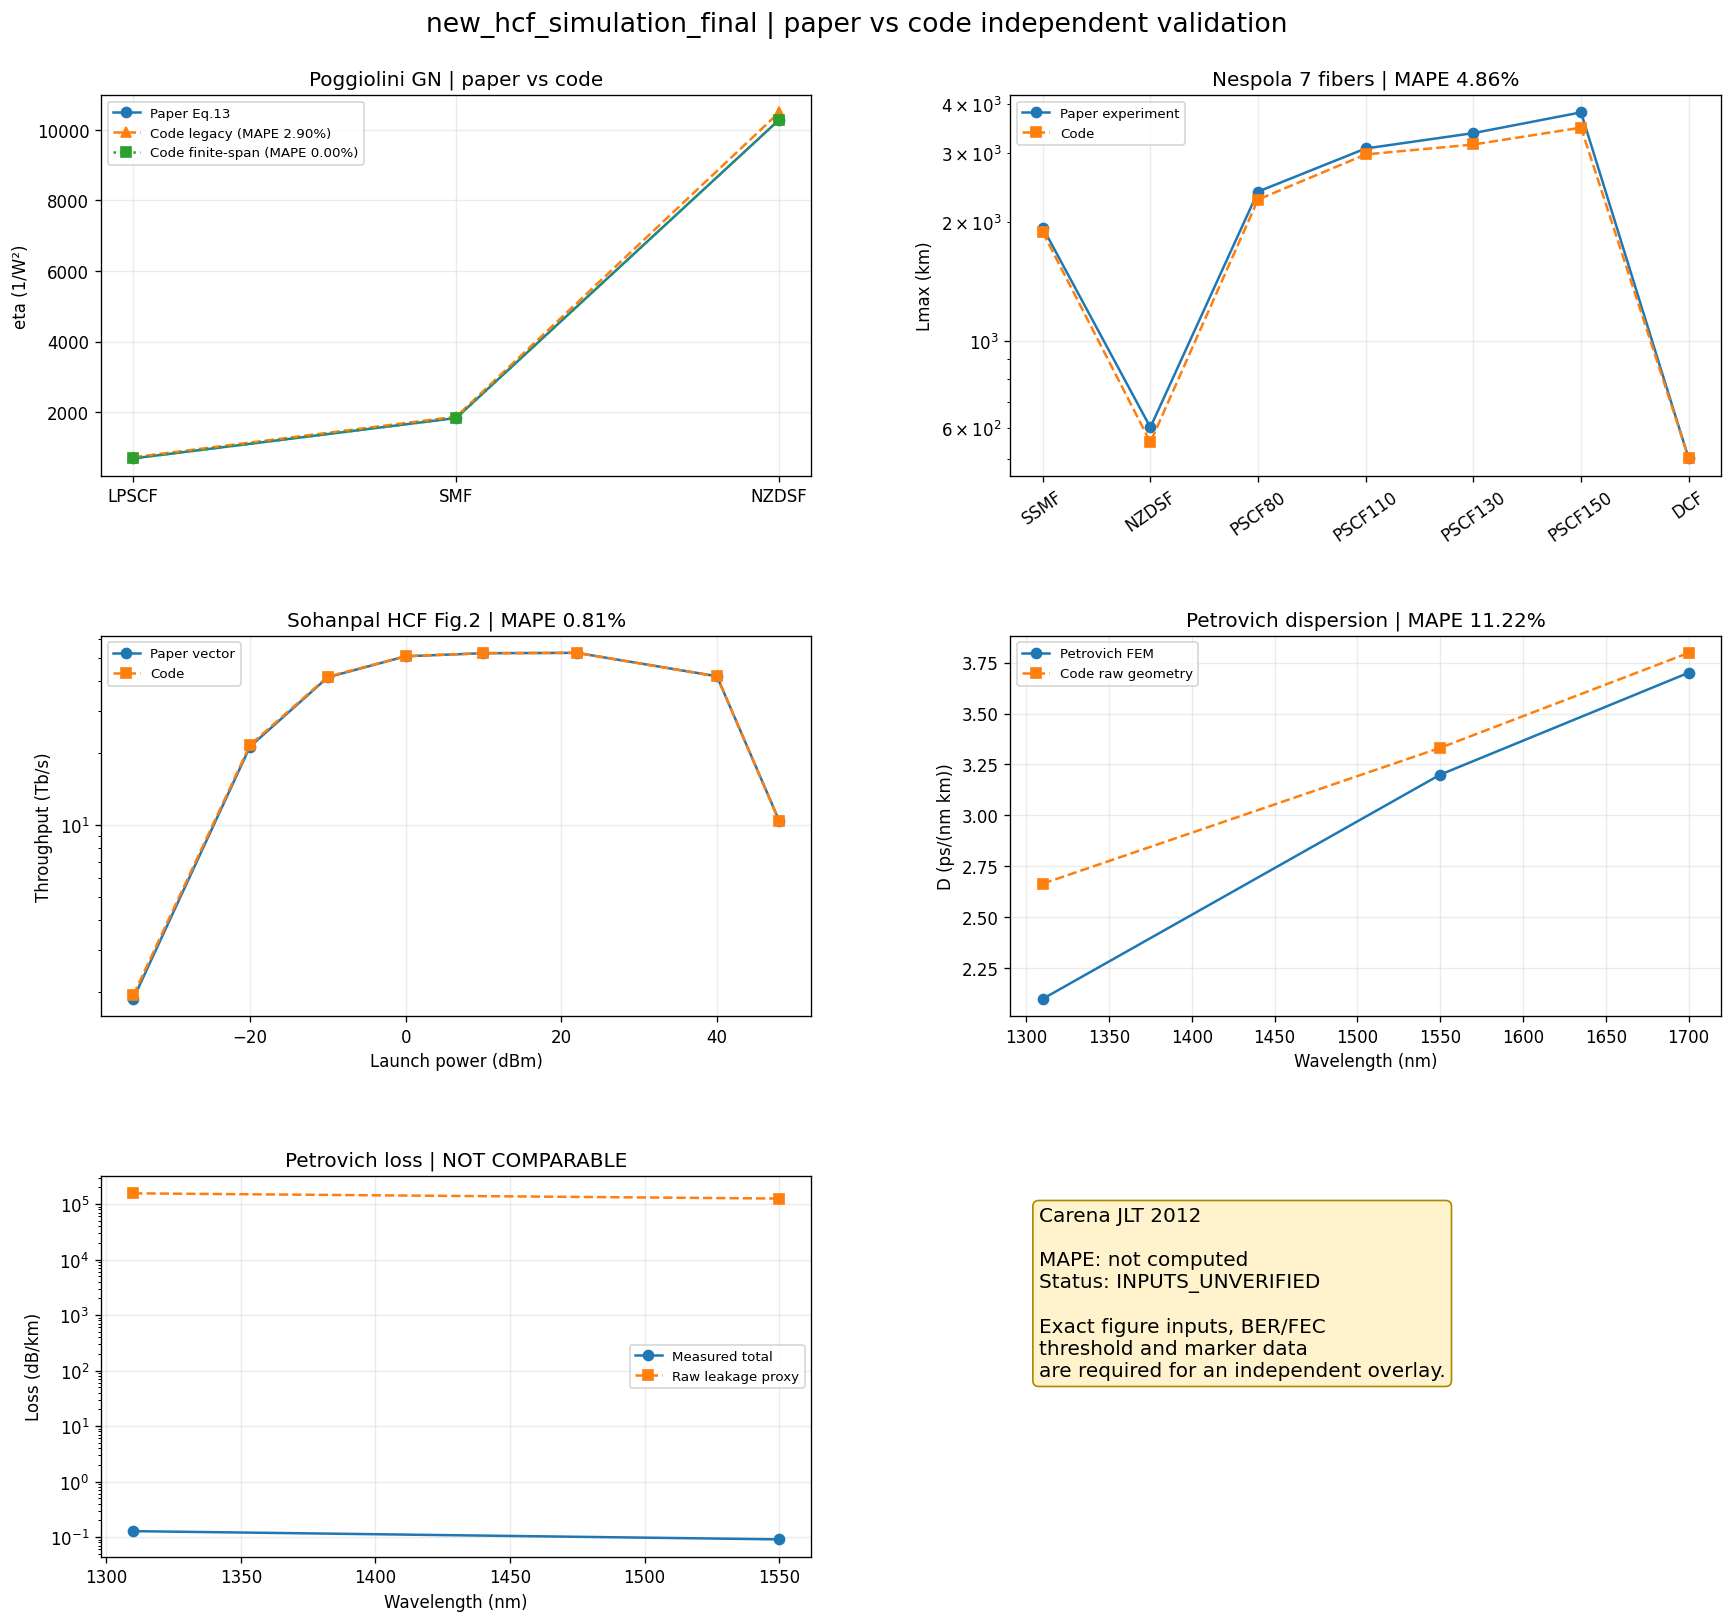

{
  "summary": [
    {
      "paper": "Poggiolini 2012",
      "quantity": "GN eta Eq.13 implementation",
      "MAPE_percent": 2.8977419003290166,
      "assessment": "PASS (<10%; equation consistency)"
    },
    {
      "paper": "Nespola 2014",
      "quantity": "7-fiber PM-16QAM Lmax",
      "MAPE_percent": 4.863462886821243,
      "assessment": "PASS (<10%; paper B2B threshold input)"
    },
    {
      "paper": "Sohanpal Fig.2",
      "quantity": "HCF throughput vs launch power",
      "MAPE_percent": 0.8143854771491262,
      "assessment": "PASS (<10%; vector reference comparison)"
    },
    {
      "paper": "Petrovich 2025",
      "quantity": "HCF dispersion raw geometry vs FEM",
      "MAPE_percent": 11.2213303417331,
      "assessment": "FAIL (>10%; geometry model limitation)"
    },
    {
      "paper": "Petrovich 2025",
      "quantity": "HCF raw leakage proxy vs measured total loss",
      "MAPE_percent": 130328642.92827803,
      "assessment": "NOT_COMPARABLE (model-laye

In [6]:
carena_status=pd.DataFrame([{
 'paper':'Carena et al. JLT 30(10), 1524–1539 (2012)',
 'quantity':'Lmax and optimum launch power for PM-BPSK/QPSK/8QAM/16QAM',
 'MAPE_percent':np.nan,
 'status':'INPUTS_UNVERIFIED',
 'reason':'Exact figure inputs and simulation marker data unavailable; no fabricated error used.'}])
save_table('06_carena_status',carena_status)
summary=pd.DataFrame([
 ['Poggiolini 2012','GN eta Eq.13 implementation',gn_summary['MAPE_percent'],'PASS (<10%; equation consistency)'],
 ['Nespola 2014','7-fiber PM-16QAM Lmax',nespola_metrics['MAPE_percent'],'PASS (<10%; paper B2B threshold input)'],
 ['Sohanpal Fig.2','HCF throughput vs launch power',s_metric['MAPE_percent'],'PASS (<10%; vector reference comparison)'],
 ['Petrovich 2025','HCF dispersion raw geometry vs FEM',hcf_disp_metrics['MAPE_percent'],'FAIL (>10%; geometry model limitation)'],
 ['Petrovich 2025','HCF raw leakage proxy vs measured total loss',hcf_loss_metrics['MAPE_percent'],'NOT_COMPARABLE (model-layer mismatch)'],
 ['Carena 2012','Four-format Lmax/optimum power',np.nan,'INPUTS_UNVERIFIED'],
],columns=['paper','quantity','MAPE_percent','assessment'])
save_table('07_validation_summary',summary)
# Combined graph: all available paper/code comparisons in one figure.
fig,axes=plt.subplots(3,2,figsize=(15,14))
fig.subplots_adjust(left=0.08,right=0.98,bottom=0.06,top=0.93,wspace=0.28,hspace=0.42)
ax=axes[0,0]; ax.plot(gn_df.fiber,gn_df.paper_Eq13_eta,'o-',label='Paper Eq.13'); ax.plot(gn_df.fiber,gn_df.existing_code_eta,'^--',label=f'Code legacy (MAPE {gn_summary["MAPE_percent"]:.2f}%)'); ax.plot(gn_df.fiber,gn_df.finite_span_eta,'s:',label=f'Code finite-span (MAPE {metrics(gn_df.finite_span_eta,gn_df.paper_Eq13_eta)["MAPE_percent"]:.2f}%)'); ax.set_ylabel('eta (1/W²)'); ax.set_title('Poggiolini GN | paper vs code'); ax.legend(fontsize=8)
ax=axes[0,1]; ax.plot(nespola_df.fiber,nespola_df.paper_Lmax_km,'o-',label='Paper experiment'); ax.plot(nespola_df.fiber,nespola_df.code_Lmax_km,'s--',label='Code'); ax.set_yscale('log'); ax.set_ylabel('Lmax (km)'); ax.tick_params(axis='x',rotation=35); ax.set_title(f'Nespola 7 fibers | MAPE {nespola_metrics["MAPE_percent"]:.2f}%'); ax.legend(fontsize=8)
ax=axes[1,0]; ax.plot(PCH,paperT,'o-',label='Paper vector'); ax.plot(PCH,codeT,'s--',label='Code'); ax.set_yscale('log'); ax.set_xlabel('Launch power (dBm)'); ax.set_ylabel('Throughput (Tb/s)'); ax.set_title(f'Sohanpal HCF Fig.2 | MAPE {s_metric["MAPE_percent"]:.2f}%'); ax.legend(fontsize=8)
ax=axes[1,1]; ax.plot(wlD,paperD,'o-',label='Petrovich FEM'); ax.plot(wlD,codeD,'s--',label='Code raw geometry'); ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('D (ps/(nm km))'); ax.set_title(f'Petrovich dispersion | MAPE {hcf_disp_metrics["MAPE_percent"]:.2f}%'); ax.legend(fontsize=8)
ax=axes[2,0]; ax.semilogy(wlL,paperL,'o-',label='Measured total'); ax.semilogy(wlL,codeL,'s--',label='Raw leakage proxy'); ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Loss (dB/km)'); ax.set_title('Petrovich loss | NOT COMPARABLE'); ax.legend(fontsize=8)
ax=axes[2,1]; ax.axis('off'); ax.text(.04,.92,'Carena JLT 2012\n\nMAPE: not computed\nStatus: INPUTS_UNVERIFIED\n\nExact figure inputs, BER/FEC\nthreshold and marker data\nare required for an independent overlay.',fontsize=12,va='top',bbox=dict(boxstyle='round',fc='#fff3cd',ec='#aa8800'))
fig.suptitle('new_hcf_simulation_final | paper vs code independent validation',fontsize=16); save_fig('00_unified_paper_code_comparison',fig)
summary_dict={'summary':summary.to_dict(orient='records'),'metrics':{'Poggiolini_eta':gn_summary,'Nespola_Lmax':nespola_metrics,'Sohanpal_Fig2':s_metric,'Petrovich_dispersion':hcf_disp_metrics,'Petrovich_loss_proxy':hcf_loss_metrics},'independence_policy':'No paper-output fitting; Carena remains INPUTS_UNVERIFIED; Petrovich loss marked NOT_COMPARABLE.'}
(RESULTS/'summary.json').write_text(json.dumps(summary_dict,ensure_ascii=False,indent=2))
(RESULTS/'README.txt').write_text('new_hcf_simulation_final results. PASS means the stated benchmark under stated assumptions is below 10%; it does not imply universal system accuracy. Petrovich loss is a layer mismatch; Carena inputs are unverified.')
shutil.make_archive('new_hcf_simulation_final_results','zip',RESULTS)
print(json.dumps(summary_dict,ensure_ascii=False,indent=2))